# Cross-Experiment PRMP Meta-Analysis

**Effect Sizes, Forest Plots & Moderator Analysis**

This notebook performs a cross-experiment meta-analysis pooling PRMP (Predictive Residual Message Passing) vs baseline results across 5 experiments (4 datasets, 9 tasks). It computes:

- **Hedges' g** standardized effect sizes for each task
- **DerSimonian-Laird** random-effects meta-analytic summary
- **Subgroup analysis** (regression vs classification)
- **WLS meta-regression** with cardinality×predictability interaction
- **Ablation validation** (random predictions)
- **Win/Loss/Draw** tally
- **Forest plot**, **funnel plot**, and **summary table**

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed for this analysis

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy==1.16.3 requires Python >=3.11 (Colab uses 3.12); use 1.15.3 for Python 3.10
    import platform
    _py_minor = int(platform.python_version_tuple()[1])
    _scipy_ver = 'scipy==1.16.3' if _py_minor >= 11 else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy_ver, 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Imports

In [2]:
import json
import math
import os
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

import numpy as np
from scipy import stats as sp_stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Data Loading

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/evaluation_iter4_cross_experimen/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['task_results'])} task results")

Loaded 9 task results


## Configuration

In [5]:
# ---- Config ----
SIGNIFICANCE_THRESHOLD = 0.05  # p-value threshold for significance
MIN_SEEDS_FOR_META = 3         # minimum seeds for inclusion in random-effects meta-analysis

## Data Structure

Define the `TaskResult` dataclass to hold per-task comparison results.

In [6]:
@dataclass
class TaskResult:
    """Per-task comparison results for meta-analysis."""
    dataset: str
    task: str
    metric_name: str
    task_type: str          # "regression" or "classification"
    higher_is_better: bool
    n_seeds: int
    baseline_mean: float
    baseline_std: float
    prmp_mean: float
    prmp_std: float
    random_mean: Optional[float] = None
    random_std: Optional[float] = None
    mean_fk_cardinality: float = 0.0
    mean_cross_table_r2: float = 0.0
    is_saturated: bool = False

# Parse task results from loaded data
all_tasks: List[TaskResult] = []
for tr in data['task_results']:
    all_tasks.append(TaskResult(
        dataset=tr['dataset'], task=tr['task'], metric_name=tr['metric_name'],
        task_type=tr['task_type'], higher_is_better=tr['higher_is_better'],
        n_seeds=tr['n_seeds'], baseline_mean=tr['baseline_mean'],
        baseline_std=tr['baseline_std'], prmp_mean=tr['prmp_mean'],
        prmp_std=tr['prmp_std'], random_mean=tr.get('random_mean'),
        random_std=tr.get('random_std'),
        mean_fk_cardinality=tr.get('mean_fk_cardinality', 0.0),
        mean_cross_table_r2=tr.get('mean_cross_table_r2', 0.0),
        is_saturated=tr.get('is_saturated', False),
    ))
print(f"Parsed {len(all_tasks)} TaskResult objects")
for t in all_tasks:
    print(f"  {t.task}: {t.metric_name}, bl={t.baseline_mean:.4f}, prmp={t.prmp_mean:.4f}, n={t.n_seeds}")

Parsed 9 TaskResult objects
  amazon-rating: RMSE, bl=0.5783, prmp=0.5343, n=3
  rel-f1-driver-dnf: AP, bl=0.9987, prmp=0.9956, n=3
  rel-f1-driver-top3: AP, bl=0.9581, prmp=0.9573, n=3
  rel-f1-driver-position: MAE, bl=4.3470, prmp=4.0037, n=3
  rel-hm-user-churn: AUROC, bl=0.5208, prmp=0.5521, n=3
  rel-hm-item-sales: MAE, bl=4.7386, prmp=4.8489, n=3
  rel-stack-user-engagement: AUROC, bl=0.8956, prmp=0.8912, n=1
  rel-stack-post-votes: MAE, bl=0.0679, prmp=0.0679, n=1
  rel-hm-fk-link-classification: AUROC, bl=0.9995, prmp=0.9828, n=1


## Statistical Functions

Core functions for computing Hedges' g, DerSimonian-Laird random-effects meta-analysis, and WLS meta-regression.

In [7]:
def compute_hedges_g(
    m_prmp: float, s_prmp: float, n_prmp: int,
    m_base: float, s_base: float, n_base: int,
    higher_is_better: bool = True,
) -> Tuple[float, float, float, float, float]:
    """Compute Hedges' g (positive = PRMP better), SE, 95% CI, p-value."""
    df = n_prmp + n_base - 2
    if df <= 0:
        return 0.0, float('inf'), float('-inf'), float('inf'), 1.0
    if s_prmp == 0 and s_base == 0:
        raw_diff = (m_prmp - m_base) if higher_is_better else (m_base - m_prmp)
        direction = 1.0 if raw_diff > 0 else (-1.0 if raw_diff < 0 else 0.0)
        return direction * 0.0, float('inf'), float('-inf'), float('inf'), 1.0

    s_pooled_sq = ((n_prmp - 1) * s_prmp**2 + (n_base - 1) * s_base**2) / df
    s_pooled = math.sqrt(max(s_pooled_sq, 1e-30))

    if higher_is_better:
        d = (m_prmp - m_base) / s_pooled
    else:
        d = (m_base - m_prmp) / s_pooled

    J = 1 - 3 / (4 * df - 1)
    g = d * J

    se = math.sqrt((n_prmp + n_base) / (n_prmp * n_base) + g**2 / (2 * df))
    ci_lower = g - 1.96 * se
    ci_upper = g + 1.96 * se

    if se > 0 and math.isfinite(se):
        z = g / se
        p_value = 2 * (1 - sp_stats.norm.cdf(abs(z)))
    else:
        p_value = 1.0
    return g, se, ci_lower, ci_upper, p_value


def dersimonian_laird(effects: List[float], variances: List[float]) -> Dict:
    """DerSimonian-Laird random-effects meta-analysis."""
    k = len(effects)
    if k == 0:
        return {"pooled_g": 0, "se": 0, "ci_lower": 0, "ci_upper": 0,
                "p_value": 1, "z": 0, "Q": 0, "Q_p_value": 1, "I2": 0, "tau2": 0, "k": 0}

    eff = np.array(effects, dtype=float)
    var = np.array(variances, dtype=float)
    var = np.clip(var, 1e-10, None)

    w = 1.0 / var
    w_sum = np.sum(w)
    g_fixed = np.sum(w * eff) / w_sum
    Q = float(np.sum(w * (eff - g_fixed)**2))

    C = w_sum - np.sum(w**2) / w_sum
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

    w_star = 1.0 / (var + tau2)
    w_star_sum = np.sum(w_star)
    g_pooled = float(np.sum(w_star * eff) / w_star_sum)
    se_pooled = float(1.0 / math.sqrt(w_star_sum))

    ci_lo = g_pooled - 1.96 * se_pooled
    ci_hi = g_pooled + 1.96 * se_pooled
    z = g_pooled / se_pooled if se_pooled > 0 else 0.0
    p_val = float(2 * (1 - sp_stats.norm.cdf(abs(z))))
    I2 = float(max(0, (Q - (k - 1)) / Q * 100)) if Q > 0 else 0.0
    Q_p = float(1 - sp_stats.chi2.cdf(Q, k - 1)) if k > 1 else 1.0

    return {"pooled_g": g_pooled, "se": se_pooled, "ci_lower": ci_lo, "ci_upper": ci_hi,
            "p_value": p_val, "z": z, "Q": Q, "Q_p_value": Q_p, "I2": I2, "tau2": tau2, "k": k}


def wls_regression(y: np.ndarray, X: np.ndarray, w: np.ndarray) -> Dict:
    """Weighted least squares meta-regression."""
    W = np.diag(w)
    k, p = X.shape
    try:
        XtWX = X.T @ W @ X
        XtWy = X.T @ W @ y
        beta = np.linalg.solve(XtWX, XtWy)
        residuals = y - X @ beta
        sigma2 = float(residuals.T @ W @ residuals / max(k - p, 1))
        cov_beta = np.linalg.inv(XtWX) * max(sigma2, 1e-10)
        se_beta = np.sqrt(np.abs(np.diag(cov_beta)))
        z_vals = beta / np.where(se_beta > 0, se_beta, 1e-10)
        p_vals = 2 * (1 - sp_stats.norm.cdf(np.abs(z_vals)))
        return {"coefficients": beta.tolist(), "standard_errors": se_beta.tolist(),
                "z_values": z_vals.tolist(), "p_values": p_vals.tolist()}
    except np.linalg.LinAlgError:
        return {"coefficients": [0.0]*p, "standard_errors": [1e6]*p,
                "z_values": [0.0]*p, "p_values": [1.0]*p}

print("Statistical functions defined.")

Statistical functions defined.


## Step 1: Compute Hedges' g for All Tasks

Compute standardized effect sizes for each task comparison (positive g = PRMP better).

In [8]:
task_effects: List[Dict] = []
for tr in all_tasks:
    g, se, ci_lo, ci_hi, pval = compute_hedges_g(
        tr.prmp_mean, tr.prmp_std, tr.n_seeds,
        tr.baseline_mean, tr.baseline_std, tr.n_seeds,
        tr.higher_is_better,
    )
    task_effects.append({
        "task": tr.task, "dataset": tr.dataset, "metric": tr.metric_name,
        "task_type": tr.task_type, "n_seeds": tr.n_seeds,
        "baseline_mean": tr.baseline_mean, "baseline_std": tr.baseline_std,
        "prmp_mean": tr.prmp_mean, "prmp_std": tr.prmp_std,
        "delta": tr.prmp_mean - tr.baseline_mean,
        "hedges_g": g, "g_se": se, "g_ci_lower": ci_lo, "g_ci_upper": ci_hi,
        "p_value": pval, "significant": pval < SIGNIFICANCE_THRESHOLD,
        "is_saturated": tr.is_saturated, "higher_is_better": tr.higher_is_better,
    })
    sig_str = " *" if pval < SIGNIFICANCE_THRESHOLD else ""
    print(f"  {tr.task}: g={g:+.3f} [{ci_lo:.3f}, {ci_hi:.3f}], p={pval:.4f}{sig_str}")

  amazon-rating: g=+3.040 [0.394, 5.686], p=0.0243 *
  rel-f1-driver-dnf: g=-1.458 [-3.351, 0.434], p=0.1310
  rel-f1-driver-top3: g=-0.088 [-1.689, 1.514], p=0.9146
  rel-f1-driver-position: g=+1.232 [-0.582, 3.045], p=0.1832
  rel-hm-user-churn: g=+1.386 [-0.481, 3.252], p=0.1456
  rel-hm-item-sales: g=-0.572 [-2.220, 1.077], p=0.4967
  rel-stack-user-engagement: g=+0.000 [-inf, inf], p=1.0000
  rel-stack-post-votes: g=+0.000 [-inf, inf], p=1.0000
  rel-hm-fk-link-classification: g=+0.000 [-inf, inf], p=1.0000


## Step 2: Random-Effects Meta-Analysis

DerSimonian-Laird pooling of tasks with ≥3 seeds.

In [9]:
primary = [te for te in task_effects if te["n_seeds"] >= MIN_SEEDS_FOR_META]
print(f"{len(primary)} primary tasks for meta-analysis")

eff_list = [te["hedges_g"] for te in primary]
var_list = [te["g_se"]**2 for te in primary]
meta = dersimonian_laird(eff_list, var_list)

print(f"\nPooled g = {meta['pooled_g']:+.4f} [{meta['ci_lower']:.4f}, {meta['ci_upper']:.4f}]")
print(f"z = {meta['z']:.3f}, p = {meta['p_value']:.6f}")
print(f"Q = {meta['Q']:.3f}, I\u00b2 = {meta['I2']:.1f}%, \u03c4\u00b2 = {meta['tau2']:.4f}")

6 primary tasks for meta-analysis

Pooled g = +0.4300 [-0.7037, 1.5636]
z = 0.743, p = 0.457246
Q = 11.048, I² = 54.7%, τ² = 1.0825


## Step 3: Subgroup Analysis

Compare regression vs classification task subgroups.

In [10]:
reg = [te for te in primary if te["task_type"] == "regression"]
cls = [te for te in primary if te["task_type"] == "classification"]
print(f"Regression tasks ({len(reg)}): {[t['task'] for t in reg]}")
print(f"Classification tasks ({len(cls)}): {[t['task'] for t in cls]}")

reg_meta = dersimonian_laird([t["hedges_g"] for t in reg], [t["g_se"]**2 for t in reg]) if len(reg) >= 2 else None
cls_meta = dersimonian_laird([t["hedges_g"] for t in cls], [t["g_se"]**2 for t in cls]) if len(cls) >= 2 else None

subgroup = {}
if reg_meta and cls_meta:
    Q_within = reg_meta["Q"] + cls_meta["Q"]
    Q_between = max(0, meta["Q"] - Q_within)
    Q_between_p = float(1 - sp_stats.chi2.cdf(Q_between, 1))

    subgroup = {
        "regression_pooled_g": reg_meta["pooled_g"],
        "regression_ci": [reg_meta["ci_lower"], reg_meta["ci_upper"]],
        "regression_p": reg_meta["p_value"],
        "classification_pooled_g": cls_meta["pooled_g"],
        "classification_ci": [cls_meta["ci_lower"], cls_meta["ci_upper"]],
        "classification_p": cls_meta["p_value"],
        "Q_between": Q_between, "Q_between_p": Q_between_p,
    }
    print(f"\nRegression pooled g = {reg_meta['pooled_g']:+.3f} (p={reg_meta['p_value']:.4f})")
    print(f"Classification pooled g = {cls_meta['pooled_g']:+.3f} (p={cls_meta['p_value']:.4f})")
    print(f"Q_between = {Q_between:.3f}, p = {Q_between_p:.4f}")

Regression tasks (3): ['amazon-rating', 'rel-f1-driver-position', 'rel-hm-item-sales']
Classification tasks (3): ['rel-f1-driver-dnf', 'rel-f1-driver-top3', 'rel-hm-user-churn']

Regression pooled g = +1.025 (p=0.2970)
Classification pooled g = -0.049 (p=0.9498)
Q_between = 1.028, p = 0.3107


## Step 4: Meta-Regression with Moderators

WLS meta-regression with cardinality×predictability interaction and task type as moderators.

In [11]:
task_map = {tr.task: tr for tr in all_tasks}
mod_names_full = ["intercept", "fk_cardinality_norm", "cross_table_r2",
                  "card_x_r2_interaction", "task_type_reg", "is_saturated"]

y_arr, X_rows, w_arr = [], [], []
for te in primary:
    tr = task_map[te["task"]]
    card = tr.mean_fk_cardinality / 100.0
    r2 = tr.mean_cross_table_r2
    row = [1.0, card, r2, card * r2,
           1.0 if tr.task_type == "regression" else 0.0,
           1.0 if tr.is_saturated else 0.0]
    y_arr.append(te["hedges_g"])
    X_rows.append(row)
    se = te["g_se"]
    w_arr.append(1.0 / (se**2) if se > 0 and math.isfinite(se) else 1.0)

y_np = np.array(y_arr)
X_np = np.array(X_rows)
w_np = np.array(w_arr)

# Determine feasible model size
k = len(y_arr)
if k > len(mod_names_full):
    mod_names = mod_names_full
    X_use = X_np
elif k > 3:
    mod_names = ["intercept", "card_x_r2_interaction", "task_type_reg"]
    X_use = X_np[:, [0, 3, 4]]
else:
    mod_names = ["intercept"]
    X_use = X_np[:, [0]]

meta_reg = wls_regression(y_np, X_use, w_np)
print("Meta-regression results:")
for nm, coef, pv in zip(mod_names, meta_reg["coefficients"], meta_reg["p_values"]):
    sig_str = " *" if pv < SIGNIFICANCE_THRESHOLD else ""
    print(f"  {nm}: \u03b2 = {coef:+.4f}, p = {pv:.4f}{sig_str}")

Meta-regression results:
  intercept: β = +0.0536, p = 0.9636
  card_x_r2_interaction: β = -3.5922, p = 0.8862
  task_type_reg: β = +0.8096, p = 0.5676


## Step 5: Ablation Validation

Check whether learned predictions are necessary by comparing random predictions vs baseline and PRMP vs random.

In [12]:
ablation_results = []
for tr in all_tasks:
    if tr.random_mean is not None and tr.n_seeds >= MIN_SEEDS_FOR_META:
        g_rb, se_rb, ci_lo_rb, ci_hi_rb, p_rb = compute_hedges_g(
            tr.random_mean, tr.random_std, tr.n_seeds,
            tr.baseline_mean, tr.baseline_std, tr.n_seeds,
            tr.higher_is_better,
        )
        g_pr, se_pr, ci_lo_pr, ci_hi_pr, p_pr = compute_hedges_g(
            tr.prmp_mean, tr.prmp_std, tr.n_seeds,
            tr.random_mean, tr.random_std, tr.n_seeds,
            tr.higher_is_better,
        )
        ablation_results.append({
            "task": tr.task,
            "random_vs_baseline_g": round(g_rb, 4),
            "prmp_vs_random_g": round(g_pr, 4),
            "learned_predictions_necessary": g_pr > g_rb,
        })
        print(f"  {tr.task}: rand_vs_bl g={g_rb:+.3f}(p={p_rb:.3f}), "
              f"prmp_vs_rand g={g_pr:+.3f}(p={p_pr:.3f})")

  amazon-rating: rand_vs_bl g=+1.820(p=0.080), prmp_vs_rand g=+1.428(p=0.137)
  rel-f1-driver-dnf: rand_vs_bl g=-1.322(p=0.160), prmp_vs_rand g=-0.394(p=0.635)
  rel-f1-driver-top3: rand_vs_bl g=-3.307(p=0.020), prmp_vs_rand g=+1.838(p=0.078)
  rel-f1-driver-position: rand_vs_bl g=-0.744(p=0.386), prmp_vs_rand g=+1.744(p=0.088)
  rel-hm-user-churn: rand_vs_bl g=+0.370(p=0.655), prmp_vs_rand g=+1.016(p=0.255)
  rel-hm-item-sales: rand_vs_bl g=-0.660(p=0.437), prmp_vs_rand g=+0.092(p=0.910)


## Step 6: Win / Loss / Draw Tally

In [13]:
wins = losses = draws = 0
wins_ns = losses_ns = draws_ns = 0
for te in task_effects:
    if te["n_seeds"] < MIN_SEEDS_FOR_META:
        continue
    if te["significant"]:
        if te["hedges_g"] > 0:
            wins += 1
            if not te["is_saturated"]: wins_ns += 1
        else:
            losses += 1
            if not te["is_saturated"]: losses_ns += 1
    else:
        draws += 1
        if not te["is_saturated"]: draws_ns += 1

print(f"All tasks:       {wins}W / {losses}L / {draws}D (of {wins+losses+draws})")
print(f"Non-saturated:   {wins_ns}W / {losses_ns}L / {draws_ns}D")

All tasks:       1W / 0L / 5D (of 6)
Non-saturated:   1W / 0L / 4D


## Step 7: Conclusion

Determine the overall hypothesis conclusion based on meta-analysis results.

In [14]:
meta_regression_out = {
    "p_values": {n: round(p, 6) for n, p in zip(mod_names, meta_reg["p_values"])},
}
pooled_pos = meta["pooled_g"] > 0
pooled_sig = meta["p_value"] < SIGNIFICANCE_THRESHOLD
interaction_p = meta_regression_out["p_values"].get("card_x_r2_interaction", 1.0)
interaction_sig = interaction_p < SIGNIFICANCE_THRESHOLD
ablation_ok = all(a["learned_predictions_necessary"] for a in ablation_results) if ablation_results else False

if pooled_sig and pooled_pos and interaction_sig and ablation_ok:
    conclusion = "CONFIRMED"
elif pooled_pos and (not pooled_sig or not interaction_sig):
    conclusion = "PARTIALLY_CONFIRMED"
elif not pooled_pos:
    conclusion = "DISCONFIRMED"
else:
    conclusion = "INCONCLUSIVE"

print(f"Conclusion: {conclusion}")
print(f"Pooled Hedges' g = {meta['pooled_g']:+.4f} [{meta['ci_lower']:.4f}, {meta['ci_upper']:.4f}]")
print(f"p = {meta['p_value']:.6f}")
print(f"I\u00b2 = {meta['I2']:.1f}%, \u03c4\u00b2 = {meta['tau2']:.4f}")
print(f"Win/Loss/Draw: {wins}W/{losses}L/{draws}D (non-sat: {wins_ns}W/{losses_ns}L/{draws_ns}D)")

Conclusion: PARTIALLY_CONFIRMED
Pooled Hedges' g = +0.4300 [-0.7037, 1.5636]
p = 0.457246
I² = 54.7%, τ² = 1.0825
Win/Loss/Draw: 1W/0L/5D (non-sat: 1W/0L/4D)


## Visualization: Forest Plot

Forest plot showing per-task Hedges' g and random-effects summary diamond.

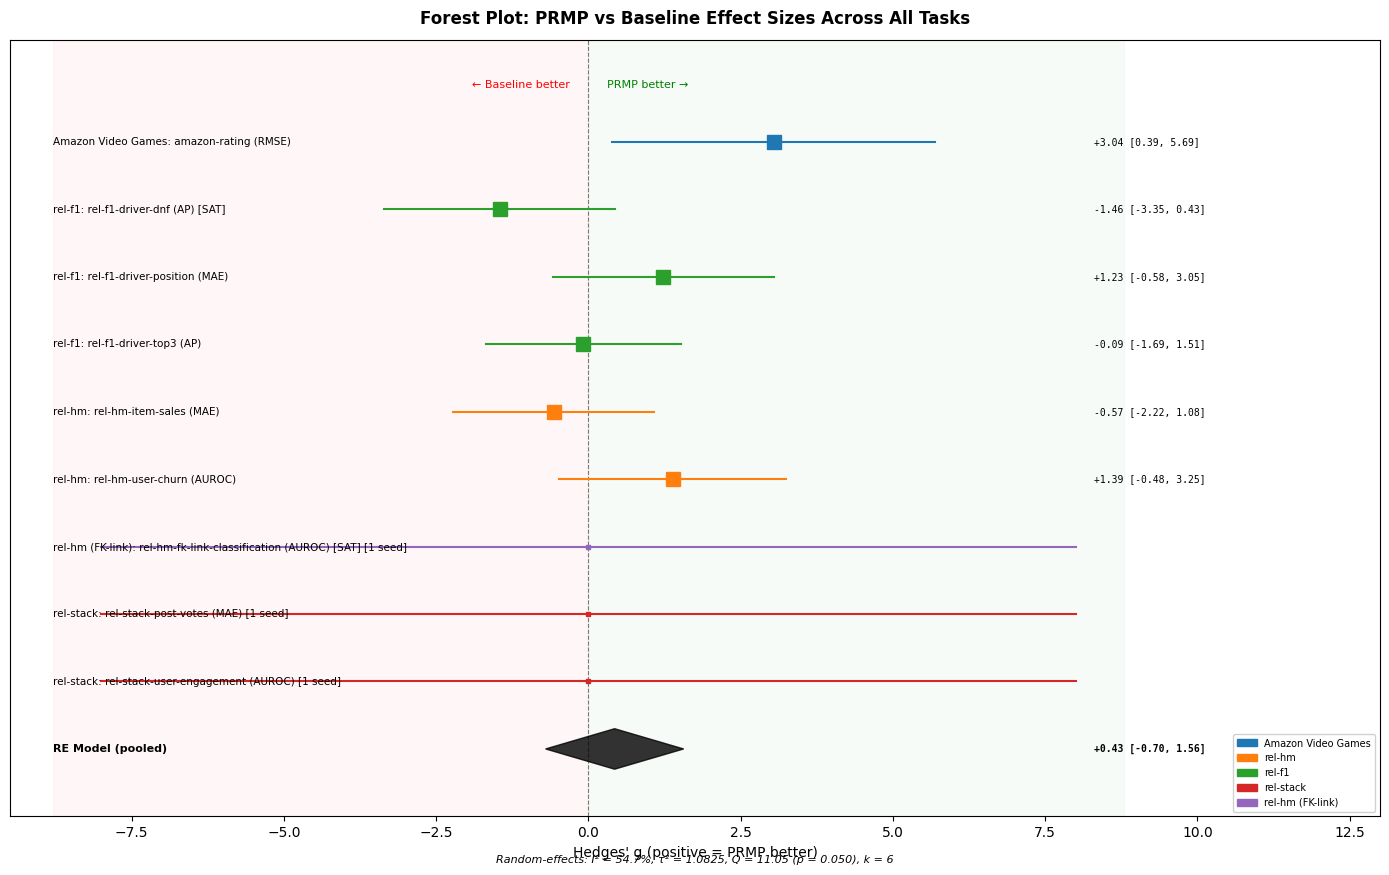

In [15]:
plot_data = []
for tr in all_tasks:
    g, se, ci_lo, ci_hi, pval = compute_hedges_g(
        tr.prmp_mean, tr.prmp_std, tr.n_seeds,
        tr.baseline_mean, tr.baseline_std, tr.n_seeds,
        tr.higher_is_better,
    )
    suffix = ""
    if tr.is_saturated: suffix = " [SAT]"
    if tr.n_seeds == 1: suffix += " [1 seed]"
    label = f"{tr.dataset}: {tr.task} ({tr.metric_name}){suffix}"
    plot_data.append((label, g, ci_lo, ci_hi, se, tr.dataset))

plot_data.sort(key=lambda x: (x[5], x[0]))
n_items = len(plot_data)

fig, ax = plt.subplots(figsize=(14, max(5, n_items * 0.7 + 2.5)))

dataset_colors = {
    "Amazon Video Games": "#1f77b4",
    "rel-hm": "#ff7f0e",
    "rel-f1": "#2ca02c",
    "rel-stack": "#d62728",
    "rel-hm (FK-link)": "#9467bd",
}

for i, (label, g, ci_lo, ci_hi, se, dataset) in enumerate(plot_data):
    y = n_items - i
    color = dataset_colors.get(dataset, "gray")
    ci_lo_d = max(ci_lo, -8)
    ci_hi_d = min(ci_hi, 8)
    ax.plot([ci_lo_d, ci_hi_d], [y, y], color=color, linewidth=1.5, zorder=2)
    w = max(3, min(10, 20 / max(se, 0.1)))
    ax.plot(g, y, 's', color=color, markersize=w, zorder=3)
    ax.text(-8.8, y, label, ha='left', va='center', fontsize=7.5)
    if math.isfinite(ci_lo) and math.isfinite(ci_hi):
        ax.text(8.3, y, f"{g:+.2f} [{ci_lo:.2f}, {ci_hi:.2f}]",
                ha='left', va='center', fontsize=7, family='monospace')

# Summary diamond
y0 = 0
gp = meta["pooled_g"]
cl, ch = meta["ci_lower"], meta["ci_upper"]
diamond_x = [cl, gp, ch, gp]
diamond_y = [y0, y0 + 0.3, y0, y0 - 0.3]
ax.fill(diamond_x, diamond_y, color='black', alpha=0.8, zorder=3)
ax.text(-8.8, y0, "RE Model (pooled)", ha='left', va='center', fontsize=8, fontweight='bold')
ax.text(8.3, y0, f"{gp:+.2f} [{cl:.2f}, {ch:.2f}]",
        ha='left', va='center', fontsize=7, fontweight='bold', family='monospace')

ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, zorder=1)
ax.axvspan(-8.8, 0, alpha=0.03, color='red')
ax.axvspan(0, 8.8, alpha=0.03, color='green')
ax.text(-0.3, n_items + 0.8, '\u2190 Baseline better', fontsize=8, color='red', ha='right')
ax.text(0.3, n_items + 0.8, 'PRMP better \u2192', fontsize=8, color='green', ha='left')

ax.set_xlim(-9.5, 13)
ax.set_ylim(-1, n_items + 1.5)
ax.set_xlabel("Hedges' g (positive = PRMP better)", fontsize=10)
ax.set_yticks([])
ax.set_title("Forest Plot: PRMP vs Baseline Effect Sizes Across All Tasks",
             fontsize=12, fontweight='bold', pad=12)

info = (f"Random-effects: I\u00b2 = {meta['I2']:.1f}%, "
        f"\u03c4\u00b2 = {meta['tau2']:.4f}, Q = {meta['Q']:.2f} "
        f"(p = {meta['Q_p_value']:.3f}), k = {meta['k']}")
ax.text(0.5, -0.06, info, transform=ax.transAxes, ha='center', fontsize=8, style='italic')

patches = [mpatches.Patch(color=c, label=d) for d, c in dataset_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=7, framealpha=0.9)

plt.tight_layout()
plt.show()

## Visualization: Funnel Plot

Funnel plot for publication bias assessment.

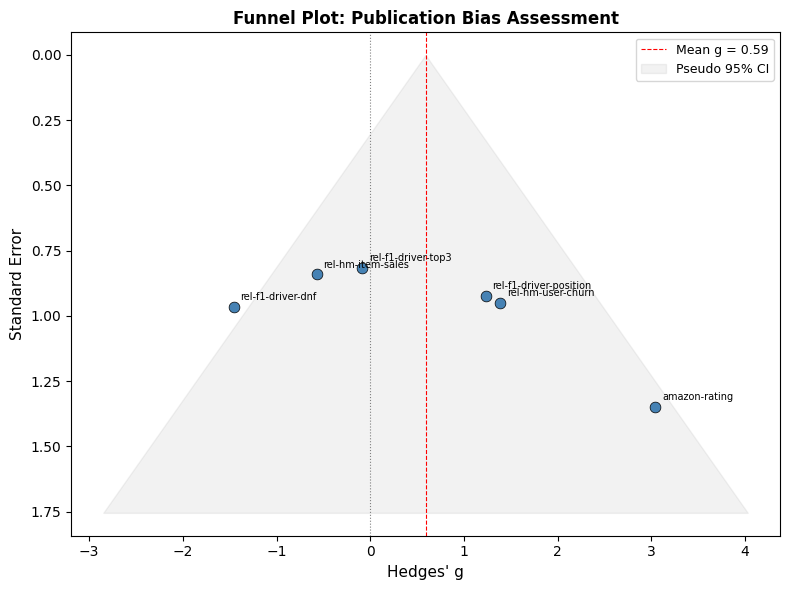

In [16]:
primary_objs = [tr for tr in all_tasks if tr.n_seeds >= MIN_SEEDS_FOR_META]
effects, ses, labels = [], [], []
for tr in primary_objs:
    g, se, _, _, _ = compute_hedges_g(
        tr.prmp_mean, tr.prmp_std, tr.n_seeds,
        tr.baseline_mean, tr.baseline_std, tr.n_seeds,
        tr.higher_is_better,
    )
    if math.isfinite(se) and se < 50:
        effects.append(g)
        ses.append(se)
        labels.append(tr.task)

if effects:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(effects, ses, s=60, c='steelblue', edgecolors='black', linewidth=0.5, zorder=3)
    for i, lab in enumerate(labels):
        ax.annotate(lab, (effects[i], ses[i]), fontsize=7, xytext=(5, 5), textcoords='offset points')

    mean_g = np.mean(effects)
    ax.axvline(x=mean_g, color='red', linestyle='--', linewidth=0.8, label=f'Mean g = {mean_g:.2f}')
    ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.8)

    se_max = max(ses) * 1.3
    se_range = np.linspace(0.001, se_max, 100)
    ax.fill_betweenx(se_range, mean_g - 1.96 * se_range, mean_g + 1.96 * se_range,
                     alpha=0.1, color='gray', label='Pseudo 95% CI')

    ax.set_xlabel("Hedges' g", fontsize=11)
    ax.set_ylabel("Standard Error", fontsize=11)
    ax.set_title("Funnel Plot: Publication Bias Assessment", fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No valid data for funnel plot")

## Summary Table

Print all task effects in a readable table format.

In [17]:
# Print summary table
print(f"{'Task':<32} {'Dataset':<20} {'Metric':<7} {'BL Mean':>10} {'PRMP Mean':>10} {'Hedges g':>10} {'95% CI':>22} {'p-value':>10} {'Sig?':>5}")
print("-" * 130)
for te in task_effects:
    g = te['hedges_g']
    ci_lo = te['g_ci_lower']
    ci_hi = te['g_ci_upper']
    ci_str = f"[{ci_lo:.2f}, {ci_hi:.2f}]" if math.isfinite(ci_lo) and math.isfinite(ci_hi) else "[inf]" 
    sig = "*" if te['significant'] else ""
    sat = " [SAT]" if te['is_saturated'] else ""
    print(f"{te['task']:<32} {te['dataset']:<20} {te['metric']:<7} {te['baseline_mean']:10.4f} {te['prmp_mean']:10.4f} {g:+10.3f} {ci_str:>22} {te['p_value']:10.4f} {sig+sat:>5}")

print()
print(f"Pooled Hedges' g = {meta['pooled_g']:+.4f}, p = {meta['p_value']:.4f}")
print(f"I\u00b2 = {meta['I2']:.1f}%, Conclusion: {conclusion}")

Task                             Dataset              Metric     BL Mean  PRMP Mean   Hedges g                 95% CI    p-value  Sig?
----------------------------------------------------------------------------------------------------------------------------------
amazon-rating                    Amazon Video Games   RMSE        0.5783     0.5343     +3.040           [0.39, 5.69]     0.0243     *
rel-f1-driver-dnf                rel-f1               AP          0.9987     0.9956     -1.458          [-3.35, 0.43]     0.1310  [SAT]
rel-f1-driver-top3               rel-f1               AP          0.9581     0.9573     -0.088          [-1.69, 1.51]     0.9146      
rel-f1-driver-position           rel-f1               MAE         4.3470     4.0037     +1.232          [-0.58, 3.05]     0.1832      
rel-hm-user-churn                rel-hm               AUROC       0.5208     0.5521     +1.386          [-0.48, 3.25]     0.1456      
rel-hm-item-sales                rel-hm               MAE 